In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
jeep_df = pd.read_csv("export_jeep_pool.csv")
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times
0,0,20,1,1.0000,0.0025,301,4432|4434,2639|15239|25352|28153|30954|33213|34894|36575...,1799|14399|22552|25353|28154|30955|33214|34895...
1,1,20,3,0.7425,0.0025,302,4421|4422|4423|4424|4425|4426|4429,2639|17039|25375|28176|30977|33226|34907|36588...,1799|16199|22575|25376|28177|30978|33227|34908...
2,2,20,1,1.0000,0.0025,291,NaN,4439|17039|25673|28474|31275|33405|35086|36767...,3599|16199|22873|25674|28475|31276|33406|35087...
3,3,20,0,0.0000,0.0025,288,4430|4431|4433,4439|18839|25655|28456|31257|33394|35075|36756...,3599|17999|22855|25656|28457|31258|33395|35076...
4,4,20,1,1.0000,0.0025,295,NaN,6239|18839|25956|28757|31558|33575|35256|36937...,5399|17999|23156|25957|28758|31559|33576|35257...
5,5,20,0,0.0000,0.0025,292,NaN,6239|20639|25900|28701|31502|33541|35222|36903...,5399|19799|23100|25901|28702|31503|33542|35223...
6,6,20,1,1.0000,0.0025,291,NaN,8039|20639|26181|28982|31783|33710|35391|37072...,7199|19799|23381|26182|28983|31784|33711|35392...
7,7,20,0,0.0000,0.0025,284,NaN,8039|24396|27197|29998|32639|34320|36001|37682...,7199|21599|24397|27198|29999|32640|34321|36002...
8,8,20,1,1.0000,0.0025,284,NaN,9839|24396|27197|29998|32639|34320|36001|37682...,8999|21599|24397|27198|29999|32640|34321|36002...
9,9,20,0,0.0000,0.0025,300,NaN,9839|24629|27430|30231|32779|34460|36141|37822...,8999|21829|24630|27431|30232|32780|34461|36142...


In [3]:
jeep_df["arrive_times"] = jeep_df["arrive_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["arrive_times"]

0     [2639, 15239, 25352, 28153, 30954, 33213, 3489...
1     [2639, 17039, 25375, 28176, 30977, 33226, 3490...
2     [4439, 17039, 25673, 28474, 31275, 33405, 3508...
3     [4439, 18839, 25655, 28456, 31257, 33394, 3507...
4     [6239, 18839, 25956, 28757, 31558, 33575, 3525...
5     [6239, 20639, 25900, 28701, 31502, 33541, 3522...
6     [8039, 20639, 26181, 28982, 31783, 33710, 3539...
7     [8039, 24396, 27197, 29998, 32639, 34320, 3600...
8     [9839, 24396, 27197, 29998, 32639, 34320, 3600...
9     [9839, 24629, 27430, 30231, 32779, 34460, 3614...
10    [11639, 24757, 27558, 30359, 32856, 34537, 362...
11    [11639, 24914, 27715, 30516, 32950, 34631, 363...
12    [13439, 25014, 27815, 30616, 33010, 34691, 363...
13    [13439, 25121, 27922, 30723, 33074, 34755, 364...
14    [15239, 25156, 27957, 30758, 33095, 34776, 364...
Name: arrive_times, dtype: object

In [4]:
jeep_df["embark_times"] = jeep_df["embark_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["embark_times"]

0     [1799, 14399, 22552, 25353, 28154, 30955, 3321...
1     [1799, 16199, 22575, 25376, 28177, 30978, 3322...
2     [3599, 16199, 22873, 25674, 28475, 31276, 3340...
3     [3599, 17999, 22855, 25656, 28457, 31258, 3339...
4     [5399, 17999, 23156, 25957, 28758, 31559, 3357...
5     [5399, 19799, 23100, 25901, 28702, 31503, 3354...
6     [7199, 19799, 23381, 26182, 28983, 31784, 3371...
7     [7199, 21599, 24397, 27198, 29999, 32640, 3432...
8     [8999, 21599, 24397, 27198, 29999, 32640, 3432...
9     [8999, 21829, 24630, 27431, 30232, 32780, 3446...
10    [10799, 21957, 24758, 27559, 30360, 32857, 345...
11    [10799, 22114, 24915, 27716, 30517, 32951, 346...
12    [12599, 22214, 25015, 27816, 30617, 33011, 346...
13    [12599, 22321, 25122, 27923, 30724, 33075, 347...
14    [14399, 22356, 25157, 27958, 30759, 33096, 347...
Name: embark_times, dtype: object

In [5]:
jeep_df["queue_start_times"] = jeep_df["arrive_times"].apply(
    lambda times: [0] + times[:-1]
)



In [6]:
jeep_df["queue_wait_times"] = jeep_df.apply(
    lambda row: [eb - qs  for qs, eb in zip(row["queue_start_times"], row["embark_times"])],
    axis=1
)

In [7]:
jeep_df[["embark_times", "arrive_times", "queue_start_times", "queue_wait_times"]].head()


,embark_times,arrive_times,queue_start_times,queue_wait_times
0,"[1799, 14399, 22552, 25353, 28154, 30955, 3321...","[2639, 15239, 25352, 28153, 30954, 33213, 3489...","[0, 2639, 15239, 25352, 28153, 30954, 33213, 3...","[1799, 11760, 7313, 1, 1, 1, 1, 1, 1, 11118, 8..."
1,"[1799, 16199, 22575, 25376, 28177, 30978, 3322...","[2639, 17039, 25375, 28176, 30977, 33226, 3490...","[0, 2639, 17039, 25375, 28176, 30977, 33226, 3...","[1799, 13560, 5536, 1, 1, 1, 1, 1, 2484, 5240,..."
2,"[3599, 16199, 22873, 25674, 28475, 31276, 3340...","[4439, 17039, 25673, 28474, 31275, 33405, 3508...","[0, 4439, 17039, 25673, 28474, 31275, 33405, 3...","[3599, 11760, 5834, 1, 1, 1, 1, 1, 351, 12376,..."
3,"[3599, 17999, 22855, 25656, 28457, 31258, 3339...","[4439, 18839, 25655, 28456, 31257, 33394, 3507...","[0, 4439, 18839, 25655, 28456, 31257, 33394, 3...","[3599, 13560, 4016, 1, 1, 1, 1, 1, 3130, 6226,..."
4,"[5399, 17999, 23156, 25957, 28758, 31559, 3357...","[6239, 18839, 25956, 28757, 31558, 33575, 3525...","[0, 6239, 18839, 25956, 28757, 31558, 33575, 3...","[5399, 11760, 4317, 1, 1, 1, 1, 1, 1161, 13196..."


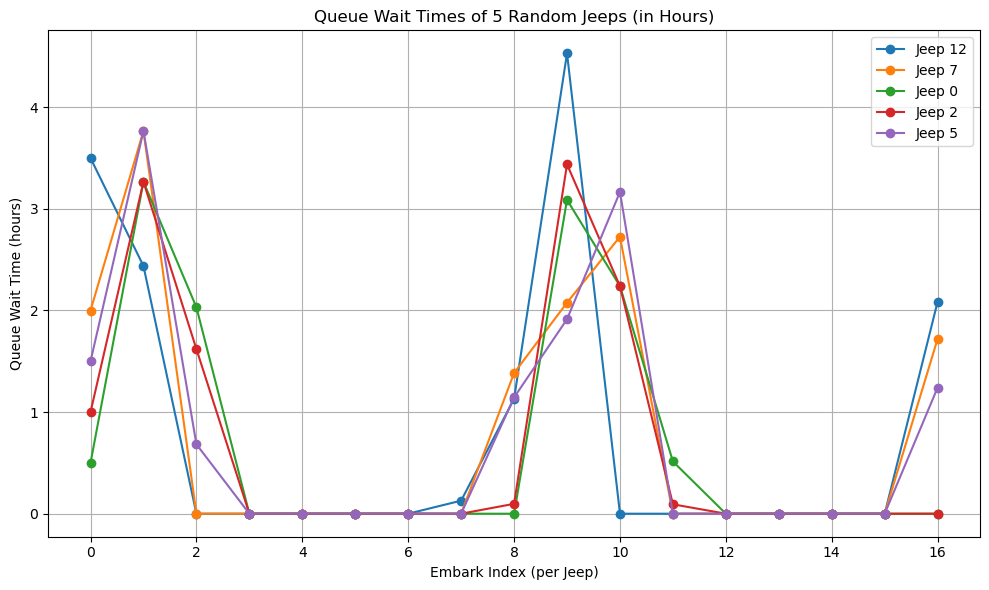

In [8]:
import random

# Randomly select 5 jeep indices
random_indices = random.sample(range(len(jeep_df)), 5)

# Plot each selected jeep's queue wait times (converted to hours)
plt.figure(figsize=(10, 6))
for idx in random_indices:
    wait_times_sec = jeep_df.loc[idx, "queue_wait_times"]
    wait_times_hr = [t / 3600 for t in wait_times_sec]  # Convert to hours
    plt.plot(range(len(wait_times_hr)), wait_times_hr, marker='o', label=f"Jeep {idx}")

plt.xlabel("Embark Index (per Jeep)")
plt.ylabel("Queue Wait Time (hours)")
plt.title("Queue Wait Times of 5 Random Jeeps (in Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
jeep_df["embark_hours"] = jeep_df["embark_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["embark_hours"]

0     [0.5, 4.0, 6.26, 7.04, 7.82, 8.6, 9.23, 9.69, ...
1     [0.5, 4.5, 6.27, 7.05, 7.83, 8.61, 9.23, 9.7, ...
2     [1.0, 4.5, 6.35, 7.13, 7.91, 8.69, 9.28, 9.75,...
3     [1.0, 5.0, 6.35, 7.13, 7.9, 8.68, 9.28, 9.74, ...
4     [1.5, 5.0, 6.43, 7.21, 7.99, 8.77, 9.33, 9.79,...
5     [1.5, 5.5, 6.42, 7.19, 7.97, 8.75, 9.32, 9.78,...
6     [2.0, 5.5, 6.49, 7.27, 8.05, 8.83, 9.36, 9.83,...
7     [2.0, 6.0, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0,...
8     [2.5, 6.0, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0,...
9     [2.5, 6.06, 6.84, 7.62, 8.4, 9.11, 9.57, 10.04...
10    [3.0, 6.1, 6.88, 7.66, 8.43, 9.13, 9.59, 10.06...
11    [3.0, 6.14, 6.92, 7.7, 8.48, 9.15, 9.62, 10.09...
12    [3.5, 6.17, 6.95, 7.73, 8.5, 9.17, 9.64, 10.23...
13    [3.5, 6.2, 6.98, 7.76, 8.53, 9.19, 9.65, 10.12...
14    [4.0, 6.21, 6.99, 7.77, 8.54, 9.19, 9.66, 10.5...
Name: embark_hours, dtype: object

In [10]:
jeep_df["arrive_hours"] = jeep_df["arrive_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["arrive_hours"]

0     [0.73, 4.23, 7.04, 7.82, 8.6, 9.23, 9.69, 10.1...
1     [0.73, 4.73, 7.05, 7.83, 8.6, 9.23, 9.7, 10.16...
2     [1.23, 4.73, 7.13, 7.91, 8.69, 9.28, 9.75, 10....
3     [1.23, 5.23, 7.13, 7.9, 8.68, 9.28, 9.74, 10.2...
4     [1.73, 5.23, 7.21, 7.99, 8.77, 9.33, 9.79, 10....
5     [1.73, 5.73, 7.19, 7.97, 8.75, 9.32, 9.78, 10....
6     [2.23, 5.73, 7.27, 8.05, 8.83, 9.36, 9.83, 10....
7     [2.23, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0, 10....
8     [2.73, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0, 10....
9     [2.73, 6.84, 7.62, 8.4, 9.11, 9.57, 10.04, 10....
10    [3.23, 6.88, 7.66, 8.43, 9.13, 9.59, 10.06, 10...
11    [3.23, 6.92, 7.7, 8.48, 9.15, 9.62, 10.09, 10....
12    [3.73, 6.95, 7.73, 8.5, 9.17, 9.64, 10.1, 10.7...
13    [3.73, 6.98, 7.76, 8.53, 9.19, 9.65, 10.12, 10...
14    [4.23, 6.99, 7.77, 8.54, 9.19, 9.66, 10.13, 11...
Name: arrive_hours, dtype: object

In [11]:
jeep_df["gross_profit"] = jeep_df["passenger_served"] * 13

jeep_df["gross_profit"]

0     3913
1     3926
2     3783
3     3744
4     3835
5     3796
6     3783
7     3692
8     3692
9     3900
10    3913
11    3978
12    3913
13    3718
14    4069
Name: gross_profit, dtype: int64

In [12]:
route_distance = 5 #change if needed
gas_price = 60
liters_per_km = 0.181818
jeep_df["gas_expense"] = len(jeep_df["embark_times"]) * route_distance * liters_per_km * gas_price

In [13]:
jeep_df["gas_expense"]

0     818.181
1     818.181
2     818.181
3     818.181
4     818.181
5     818.181
6     818.181
7     818.181
8     818.181
9     818.181
10    818.181
11    818.181
12    818.181
13    818.181
14    818.181
Name: gas_expense, dtype: float64

In [14]:
jeep_df["net_profit"] = jeep_df["gross_profit"] - jeep_df["gas_expense"]

In [15]:
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times,queue_start_times,queue_wait_times,embark_hours,arrive_hours,gross_profit,gas_expense,net_profit
0,0,20,1,1.0000,0.0025,301,4432|4434,"[2639, 15239, 25352, 28153, 30954, 33213, 3489...","[1799, 14399, 22552, 25353, 28154, 30955, 3321...","[0, 2639, 15239, 25352, 28153, 30954, 33213, 3...","[1799, 11760, 7313, 1, 1, 1, 1, 1, 1, 11118, 8...","[0.5, 4.0, 6.26, 7.04, 7.82, 8.6, 9.23, 9.69, ...","[0.73, 4.23, 7.04, 7.82, 8.6, 9.23, 9.69, 10.1...",3913,818.181,3094.819
1,1,20,3,0.7425,0.0025,302,4421|4422|4423|4424|4425|4426|4429,"[2639, 17039, 25375, 28176, 30977, 33226, 3490...","[1799, 16199, 22575, 25376, 28177, 30978, 3322...","[0, 2639, 17039, 25375, 28176, 30977, 33226, 3...","[1799, 13560, 5536, 1, 1, 1, 1, 1, 2484, 5240,...","[0.5, 4.5, 6.27, 7.05, 7.83, 8.61, 9.23, 9.7, ...","[0.73, 4.73, 7.05, 7.83, 8.6, 9.23, 9.7, 10.16...",3926,818.181,3107.819
2,2,20,1,1.0000,0.0025,291,NaN,"[4439, 17039, 25673, 28474, 31275, 33405, 3508...","[3599, 16199, 22873, 25674, 28475, 31276, 3340...","[0, 4439, 17039, 25673, 28474, 31275, 33405, 3...","[3599, 11760, 5834, 1, 1, 1, 1, 1, 351, 12376,...","[1.0, 4.5, 6.35, 7.13, 7.91, 8.69, 9.28, 9.75,...","[1.23, 4.73, 7.13, 7.91, 8.69, 9.28, 9.75, 10....",3783,818.181,2964.819
3,3,20,0,0.0000,0.0025,288,4430|4431|4433,"[4439, 18839, 25655, 28456, 31257, 33394, 3507...","[3599, 17999, 22855, 25656, 28457, 31258, 3339...","[0, 4439, 18839, 25655, 28456, 31257, 33394, 3...","[3599, 13560, 4016, 1, 1, 1, 1, 1, 3130, 6226,...","[1.0, 5.0, 6.35, 7.13, 7.9, 8.68, 9.28, 9.74, ...","[1.23, 5.23, 7.13, 7.9, 8.68, 9.28, 9.74, 10.2...",3744,818.181,2925.819
4,4,20,1,1.0000,0.0025,295,NaN,"[6239, 18839, 25956, 28757, 31558, 33575, 3525...","[5399, 17999, 23156, 25957, 28758, 31559, 3357...","[0, 6239, 18839, 25956, 28757, 31558, 33575, 3...","[5399, 11760, 4317, 1, 1, 1, 1, 1, 1161, 13196...","[1.5, 5.0, 6.43, 7.21, 7.99, 8.77, 9.33, 9.79,...","[1.73, 5.23, 7.21, 7.99, 8.77, 9.33, 9.79, 10....",3835,818.181,3016.819
5,5,20,0,0.0000,0.0025,292,NaN,"[6239, 20639, 25900, 28701, 31502, 33541, 3522...","[5399, 19799, 23100, 25901, 28702, 31503, 3354...","[0, 6239, 20639, 25900, 28701, 31502, 33541, 3...","[5399, 13560, 2461, 1, 1, 1, 1, 1, 4119, 6890,...","[1.5, 5.5, 6.42, 7.19, 7.97, 8.75, 9.32, 9.78,...","[1.73, 5.73, 7.19, 7.97, 8.75, 9.32, 9.78, 10....",3796,818.181,2977.819
6,6,20,1,1.0000,0.0025,291,NaN,"[8039, 20639, 26181, 28982, 31783, 33710, 3539...","[7199, 19799, 23381, 26182, 28983, 31784, 3371...","[0, 8039, 20639, 26181, 28982, 31783, 33710, 3...","[7199, 11760, 2742, 1, 1, 1, 1, 1, 2022, 14000...","[2.0, 5.5, 6.49, 7.27, 8.05, 8.83, 9.36, 9.83,...","[2.23, 5.73, 7.27, 8.05, 8.83, 9.36, 9.83, 10....",3783,818.181,2964.819
7,7,20,0,0.0000,0.0025,284,NaN,"[8039, 24396, 27197, 29998, 32639, 34320, 3600...","[7199, 21599, 24397, 27198, 29999, 32640, 3432...","[0, 8039, 24396, 27197, 29998, 32639, 34320, 3...","[7199, 13560, 1, 1, 1, 1, 1, 1, 4984, 7476, 98...","[2.0, 6.0, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0,...","[2.23, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0, 10....",3692,818.181,2873.819
8,8,20,1,1.0000,0.0025,284,NaN,"[9839, 24396, 27197, 29998, 32639, 34320, 3600...","[8999, 21599, 24397, 27198, 29999, 32640, 3432...","[0, 9839, 24396, 27197, 29998, 32639, 34320, 3...","[8999, 11760, 1, 1, 1, 1, 1, 1, 2644, 14568, 4...","[2.5, 6.0, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0,...","[2.73, 6.78, 7.55, 8.33, 9.07, 9.53, 10.0, 10....",3692,818.181,2873.819
9,9,20,0,0.0000,0.0025,300,NaN,"[9839, 24629, 27430, 30231, 32779, 34460, 3614...","[8999, 21829, 24630, 27431, 30232, 32780, 3446...","[0, 9839, 24629, 27430, 30231, 32779, 34460, 3...","[8999, 11990, 1, 1, 1, 1, 1, 1, 6546, 7774, 82...","[2.5, 6.06, 6.84, 7.62, 8.4, 9.11, 9.57, 10.04...","[2.73, 6.84, 7.62, 8.4, 9.11, 9.57, 10.04, 10....",3900,818.181,3081.819


In [16]:
passenger_df = pd.read_csv("export_passenger_pool.csv")

passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]] = passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]].apply(lambda times: [round(int(t) / 3600, 2) for t in times] )

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal
0,0,0.09,0.09,0.5,0.73,0,0
1,1,0.12,0.12,0.5,0.73,0,0
2,2,0.19,0.19,0.5,0.73,1,1
3,3,0.22,0.22,0.5,0.73,0,0
4,4,0.40,0.40,0.5,0.73,1,1
...,...,...,...,...,...,...,...
4430,4430,23.86,23.86,0.0,0.00,3,0
4431,4431,23.93,23.93,0.0,0.00,3,0
4432,4432,23.94,23.94,0.0,0.00,0,1
4433,4433,23.99,23.99,0.0,0.00,3,0


In [17]:
passenger_df["turn_around_time"] = passenger_df["destination_arrival_time"] - passenger_df["terminal_arrival_time"]

passenger_df = passenger_df[passenger_df["turn_around_time"] > 0]

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.09,0.09,0.50,0.73,0,0,0.64
1,1,0.12,0.12,0.50,0.73,0,0,0.61
2,2,0.19,0.19,0.50,0.73,1,1,0.54
3,3,0.22,0.22,0.50,0.73,0,0,0.51
4,4,0.40,0.40,0.50,0.73,1,1,0.33
...,...,...,...,...,...,...,...,...
4416,4416,23.19,23.19,23.31,23.57,14,0,0.38
4417,4417,23.21,23.21,23.31,23.57,14,0,0.36
4418,4418,23.29,23.29,23.31,23.57,14,0,0.28
4419,4419,23.29,23.29,23.31,23.57,14,0,0.28


In [18]:
terminal_0_df = passenger_df[passenger_df["terminal"] == 0]
terminal_1_df = passenger_df[passenger_df["terminal"] == 1]


In [19]:
terminal_0_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.09,0.09,0.50,0.73,0,0,0.64
1,1,0.12,0.12,0.50,0.73,0,0,0.61
3,3,0.22,0.22,0.50,0.73,0,0,0.51
6,6,0.57,0.57,1.00,1.23,2,0,0.66
7,7,0.78,0.78,1.00,1.23,2,0,0.45
...,...,...,...,...,...,...,...,...
4414,4414,23.16,23.16,23.31,23.57,14,0,0.41
4416,4416,23.19,23.19,23.31,23.57,14,0,0.38
4417,4417,23.21,23.21,23.31,23.57,14,0,0.36
4418,4418,23.29,23.29,23.31,23.57,14,0,0.28


In [20]:
terminal_1_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
2,2,0.19,0.19,0.50,0.73,1,1,0.54
4,4,0.40,0.40,0.50,0.73,1,1,0.33
5,5,0.57,0.57,1.00,1.23,3,1,0.66
8,8,1.09,1.09,1.50,1.73,5,1,0.64
9,9,1.13,1.13,1.50,1.73,5,1,0.60
...,...,...,...,...,...,...,...,...
4410,4410,23.10,23.10,23.38,23.64,11,1,0.54
4411,4411,23.13,23.13,23.38,23.64,11,1,0.51
4413,4413,23.15,23.15,23.38,23.64,11,1,0.49
4415,4415,23.19,23.19,23.38,23.64,11,1,0.45


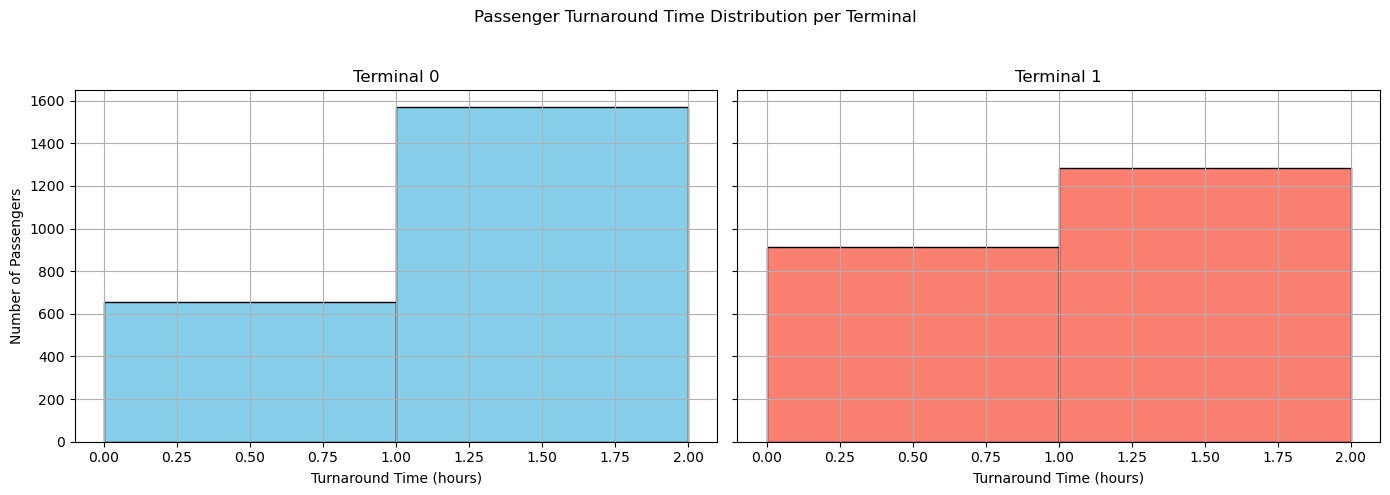

In [21]:

# Define bins (hourly intervals)
max_turnaround = max(terminal_0_df["turn_around_time"].max(), terminal_1_df["turn_around_time"].max())
bins = range(0, int(max_turnaround) + 2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Terminal 0 histogram
axs[0].hist(terminal_0_df["turn_around_time"], bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title("Terminal 0")
axs[0].set_xlabel("Turnaround Time (hours)")
axs[0].set_ylabel("Number of Passengers")
axs[0].grid(True)

# Terminal 1 histogram
axs[1].hist(terminal_1_df["turn_around_time"], bins=bins, color='salmon', edgecolor='black')
axs[1].set_title("Terminal 1")
axs[1].set_xlabel("Turnaround Time (hours)")
axs[1].grid(True)

plt.suptitle("Passenger Turnaround Time Distribution per Terminal")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

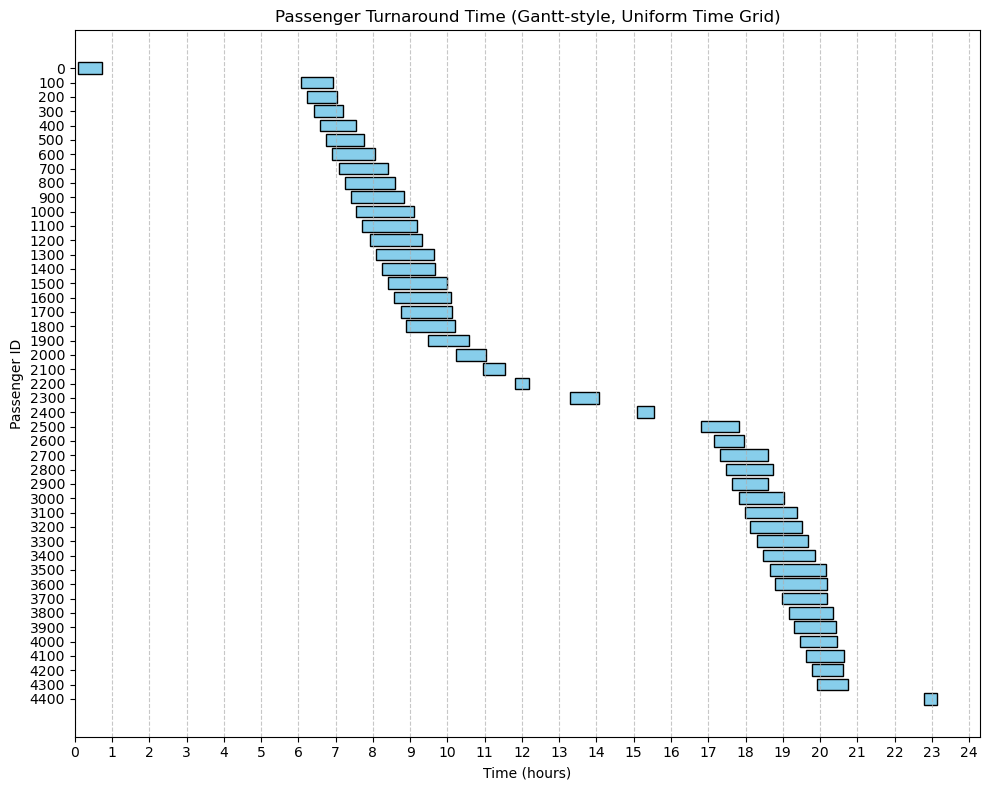

In [22]:

sample_df = passenger_df.iloc[::100].copy()

# Sample by index increments (e.g., every 100th row)
sample_df = passenger_df.iloc[::100].copy()

# Prepare data
starts = sample_df["terminal_arrival_time"]
durations = sample_df["turn_around_time"]
passenger_ids = sample_df["passenger_id"].astype(str)

# Set figure
plt.figure(figsize=(10, 8))
plt.barh(passenger_ids, durations, left=starts, color='skyblue', edgecolor='black')

# Set x-axis gridlines and ticks at every 1 hour
xmin = int(sample_df["terminal_arrival_time"].min())
xmax = int(sample_df["destination_arrival_time"].max()) + 1
plt.xticks(np.arange(xmin, xmax + 1, 1))  # every 1 hour
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Labels and layout
plt.xlabel("Time (hours)")
plt.ylabel("Passenger ID")
plt.title("Passenger Turnaround Time (Gantt-style, Uniform Time Grid)")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

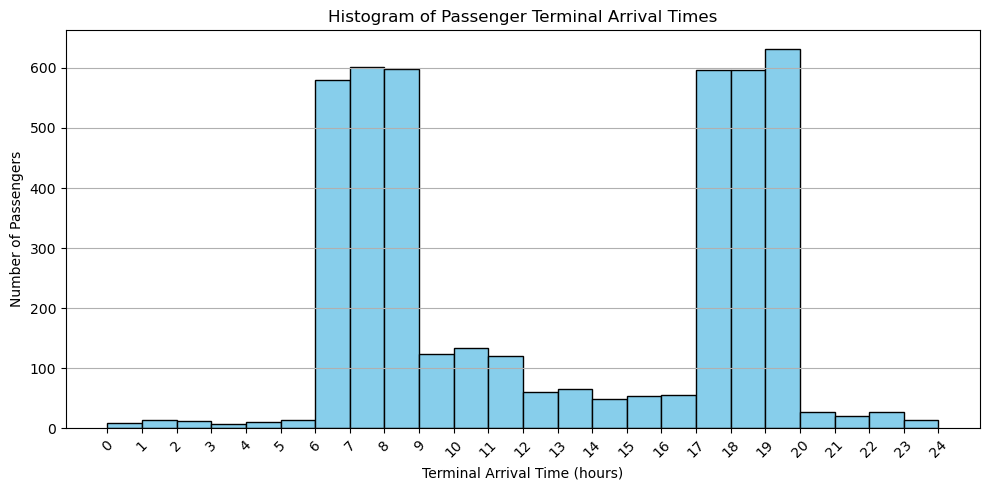

In [23]:
# Define bins: from min to max time, 1-hour step
min_time = int(passenger_df["terminal_arrival_time"].min())
max_time = int(passenger_df["terminal_arrival_time"].max()) + 1
bins = np.arange(min_time, max_time + 1, 1)  # 1-hour bins

# Plot
plt.figure(figsize=(10, 5))
plt.hist(passenger_df["terminal_arrival_time"], bins=bins, color='skyblue', edgecolor='black')

# Labels and styling
plt.xlabel("Terminal Arrival Time (hours)")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Terminal Arrival Times")
plt.grid(True, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

In [24]:
average_net_profit = jeep_df['net_profit'].mean()
print(average_net_profit)

3025.4856666666674
